# PROJECT TITLE: PREDICTING BITCOIN CLOSE PRICE

## INTRODUCTION

#### About bitcoin: 

- Bitcoin is a virtual and decenralized currency designed to act as money and a form of payment outside the <br>
control of any one person, group or entity. Hence, removing the need for third-party involvement in financial transactions.<br>
Bitcoin was introduced to the public in 2009 by a group of developers using the name Satoshi Nakamoto.

#### About this project.

-  In this piece of work, we use the LSTM (Long and Short-Term Memory) model to predict the future close price of Bitcoin using<br> historic bitcoin data from 01.01.2022 to 27.01.2023. The data used in this project was downloaded from yahoo finance.


- The dataset used in this python project is called BTC-USD.csv which has 392 rows and 7 columns (Date, Open, High, Low, Close, <br>Adj Close, Volume). Our focus will be on the ' Close ' price. We built a neural network which learned from our data. <br> In the end we visualized our predictions. 


- To make this predictions we effected the following procedures outlined below.



### 1. Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import datetime as dt
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

### 2. Read the bitcoin data downloaded from yahoo finance.

In [2]:
data = pd.read_csv('BTC-USD.csv', parse_dates=['Date'])
data.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
387,2023-01-23,22721.087891,23126.486328,22654.304688,22934.431641,22934.431641,2.651870e+10
388,2023-01-24,22929.626953,23134.011719,22549.744141,22636.468750,22636.468750,2.640507e+10
389,2023-01-25,22639.267578,23722.099609,22406.076172,23117.859375,23117.859375,3.068537e+10
390,2023-01-26,23108.955078,23237.078125,22911.373047,23032.777344,23032.777344,2.635784e+10
391,2023-01-27,NaN,NaN,NaN,NaN,NaN,NaN


### 3. We next do some exploratory data analysis.

In [3]:
#Set the index column to be the date column.

data.set_index('Date', inplace=True)
data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-01,46311.746094,47827.312500,46288.484375,47686.812500,47686.812500,2.458267e+10
2022-01-02,47680.925781,47881.406250,46856.937500,47345.218750,47345.218750,2.795157e+10
2022-01-03,47343.542969,47510.726563,45835.964844,46458.117188,46458.117188,3.307163e+10
2022-01-04,46458.851563,47406.546875,45752.464844,45897.574219,45897.574219,4.249468e+10
2022-01-05,45899.359375,46929.046875,42798.222656,43569.003906,43569.003906,3.685108e+10
...,...,...,...,...,...,...
2023-01-23,22721.087891,23126.486328,22654.304688,22934.431641,22934.431641,2.651870e+10
2023-01-24,22929.626953,23134.011719,22549.744141,22636.468750,22636.468750,2.640507e+10
2023-01-25,22639.267578,23722.099609,22406.076172,23117.859375,23117.859375,3.068537e+10


In [4]:
#We check for any null rows and columns, if there happens

data.isna().any()

Open         True
High         True
Low          True
Close        True
Adj Close    True
Volume       True
dtype: bool

In [5]:
data['Close'].mean()

27631.94036232734

In [6]:
data['Close'].isnull().value_counts()

False    391
True       1
Name: Close, dtype: int64

In [7]:
#We are concerned only with the close column, so we replace the any null value with the mean close price.

In [8]:
# replace NaN entries with mean close price
data['Close'].fillna(data['Close'].mean(), inplace=True)
data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-01,46311.746094,47827.312500,46288.484375,47686.812500,47686.812500,2.458267e+10
2022-01-02,47680.925781,47881.406250,46856.937500,47345.218750,47345.218750,2.795157e+10
2022-01-03,47343.542969,47510.726563,45835.964844,46458.117188,46458.117188,3.307163e+10
2022-01-04,46458.851563,47406.546875,45752.464844,45897.574219,45897.574219,4.249468e+10
2022-01-05,45899.359375,46929.046875,42798.222656,43569.003906,43569.003906,3.685108e+10
...,...,...,...,...,...,...
2023-01-23,22721.087891,23126.486328,22654.304688,22934.431641,22934.431641,2.651870e+10
2023-01-24,22929.626953,23134.011719,22549.744141,22636.468750,22636.468750,2.640507e+10
2023-01-25,22639.267578,23722.099609,22406.076172,23117.859375,23117.859375,3.068537e+10


In [9]:
#Ensure the data have the correct type
data.dtypes

Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume       float64
dtype: object

In [10]:
#Filter out only the close column and is assigned to a new variable called data_new.

data_new = data.filter(['Close'])

#We next convert our new data to numpy array
close_array = data_new.values
print(close_array)

[[47686.8125    ]
 [47345.21875   ]
 [46458.117188  ]
 [45897.574219  ]
 [43569.003906  ]
 [43160.929688  ]
 [41557.902344  ]
 [41733.941406  ]
 [41911.601563  ]
 [41821.261719  ]
 [42735.855469  ]
 [43949.101563  ]
 [42591.570313  ]
 [43099.699219  ]
 [43177.398438  ]
 [43113.878906  ]
 [42250.550781  ]
 [42375.632813  ]
 [41744.328125  ]
 [40680.417969  ]
 [36457.316406  ]
 [35030.25      ]
 [36276.804688  ]
 [36654.328125  ]
 [36954.003906  ]
 [36852.121094  ]
 [37138.234375  ]
 [37784.332031  ]
 [38138.179688  ]
 [37917.601563  ]
 [38483.125     ]
 [38743.273438  ]
 [36952.984375  ]
 [37154.601563  ]
 [41500.875     ]
 [41441.164063  ]
 [42412.433594  ]
 [43840.285156  ]
 [44118.445313  ]
 [44338.796875  ]
 [43565.113281  ]
 [42407.9375    ]
 [42244.46875   ]
 [42197.515625  ]
 [42586.917969  ]
 [44575.203125  ]
 [43961.859375  ]
 [40538.011719  ]
 [40030.976563  ]
 [40122.15625   ]
 [38431.378906  ]
 [37075.28125   ]
 [38286.027344  ]
 [37296.570313  ]
 [38332.609375  ]
 [39214.21

### 4. We visualze our data

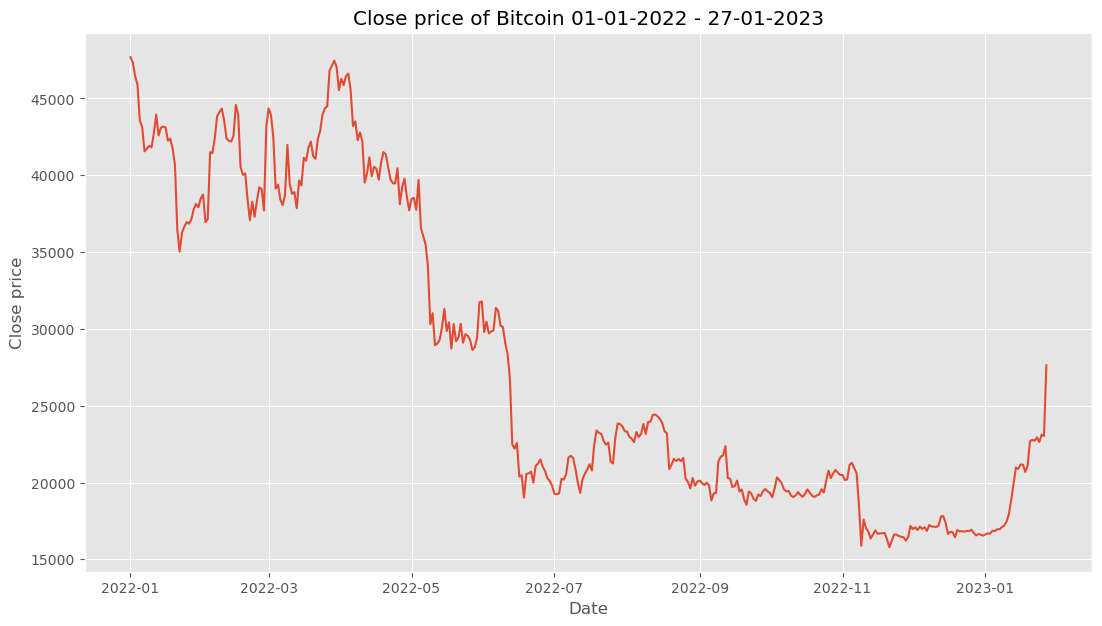

In [11]:
plt.figure(figsize=(13, 7))
plt.plot(data_new['Close'])
plt.title('Close price of Bitcoin 01-01-2022 - 27-01-2023')
plt.xlabel('Date')
plt.ylabel('Close price')
plt.grid(True)
plt.show()

### 5. We scale our close_array data using the MinMaxScaler to values between 0 and 1

In [12]:
#We scale our data using the MinMaxScaler

scaler = MinMaxScaler(feature_range = (0,1))

#scaled_data = scaler.fit_transform(data_new['Close'].values.reshape(-1, 1))

scaled_data = scaler.fit_transform(close_array)

print(scaled_data.shape)

print()

(392, 1)



In [13]:
#Get the length of our training data.

len_training_data = int(len(close_array)*0.80)

#The idea is to train our model with 80% of the our close data


### 6. Get the train and test data set from our scaled data.

In [14]:
#Train data

train_data = scaled_data[0:len_training_data]

#or we can use;
#len_training_data = math.ceil(len(close_array)*0.80)
#len_training_data
print(train_data)

[[1.        ]
 [0.98929157]
 [0.96148234]
 [0.9439102 ]
 [0.87091318]
 [0.8581207 ]
 [0.80786831]
 [0.81338686]
 [0.81895623]
 [0.81612422]
 [0.84479529]
 [0.88282865]
 [0.84027218]
 [0.85620122]
 [0.85863697]
 [0.85664573]
 [0.82958175]
 [0.83350288]
 [0.81371247]
 [0.78036056]
 [0.64797297]
 [0.60323669]
 [0.64231422]
 [0.65414898]
 [0.66354335]
 [0.66034948]
 [0.66931868]
 [0.68957282]
 [0.70066539]
 [0.69375061]
 [0.71147888]
 [0.71963413]
 [0.66351138]
 [0.66983177]
 [0.8060806 ]
 [0.80420875]
 [0.83465652]
 [0.87941742]
 [0.88813731]
 [0.89504498]
 [0.87079122]
 [0.83451558]
 [0.82939109]
 [0.82791918]
 [0.84012633]
 [0.90245594]
 [0.88322858]
 [0.77589635]
 [0.76000159]
 [0.76285993]
 [0.70985673]
 [0.6673452 ]
 [0.70530018]
 [0.67428226]
 [0.70676046]
 [0.73439752]
 [0.73097834]
 [0.6872359 ]
 [0.8591334 ]
 [0.89554153]
 [0.88204542]
 [0.83589026]
 [0.73199582]
 [0.74023984]
 [0.70949953]
 [0.6982785 ]
 [0.71944592]
 [0.82119213]
 [0.74139581]
 [0.72125482]
 [0.72467302]
 [0.69

In [15]:
#Test data

test_data = scaled_data[len_training_data - 30:,:]

print(test_data.shape)

(109, 1)


### 7. Train our data using the LSTM model

In [16]:
#We want to predict the close of the next 30 days

future_days = 30

#we create an X_train, y_train empty list

X_train = []
y_train = []

for i in range(future_days, len(train_data)):
    X_train.append(train_data[i-30: i, 0])
    y_train.append(train_data[i, 0])
    if i <= 30:
        print(X_train)
        print(y_train)
        print()

[array([1.        , 0.98929157, 0.96148234, 0.9439102 , 0.87091318,
       0.8581207 , 0.80786831, 0.81338686, 0.81895623, 0.81612422,
       0.84479529, 0.88282865, 0.84027218, 0.85620122, 0.85863697,
       0.85664573, 0.82958175, 0.83350288, 0.81371247, 0.78036056,
       0.64797297, 0.60323669, 0.64231422, 0.65414898, 0.66354335,
       0.66034948, 0.66931868, 0.68957282, 0.70066539, 0.69375061])]
[0.7114788843373092]



In [17]:
#Converting the X_train and y_train data to NumPy array

X_train = np.array(X_train)
y_train = np.array(y_train)
print(X_train)
print(y_train)
print()

[[1.         0.98929157 0.96148234 ... 0.68957282 0.70066539 0.69375061]
 [0.98929157 0.96148234 0.9439102  ... 0.70066539 0.69375061 0.71147888]
 [0.96148234 0.9439102  0.87091318 ... 0.69375061 0.71147888 0.71963413]
 ...
 [0.11377235 0.11470833 0.1051489  ... 0.16802588 0.17227237 0.1611059 ]
 [0.11470833 0.1051489  0.10232546 ... 0.17227237 0.1611059  0.15095936]
 [0.1051489  0.10232546 0.10564925 ... 0.1611059  0.15095936 0.08633317]]
[0.71147888 0.71963413 0.66351138 0.66983177 0.8060806  0.80420875
 0.83465652 0.87941742 0.88813731 0.89504498 0.87079122 0.83451558
 0.82939109 0.82791918 0.84012633 0.90245594 0.88322858 0.77589635
 0.76000159 0.76285993 0.70985673 0.6673452  0.70530018 0.67428226
 0.70676046 0.73439752 0.73097834 0.6872359  0.8591334  0.89554153
 0.88204542 0.83589026 0.73199582 0.74023984 0.70949953 0.6982785
 0.71944592 0.82119213 0.74139581 0.72125482 0.72467302 0.69162088
 0.74858379 0.73830248 0.79489092 0.78885476 0.81549394 0.82770403
 0.79814785 0.7928240

In [18]:
#Next we reshape the train data, we reshape because data because the LSTM model uses 3D but out data is in 2D

In [19]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1 ))
print(X_train.shape)

(283, 30, 1)


In [20]:
#Next we build the LSTM model

In [21]:
#Create a Neural Network

model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))

model.add(Dropout(0.2)) #The dropout layer is added to avoid overfitting

model.add(LSTM(units=50, return_sequences=True))

model.add(Dropout(0.2))

model.add(LSTM(units=50))

model.add(Dropout(0.2))

model.add(Dense(units=1))

In [22]:
#Then we compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

#An optimizer is used to improve upon the loss function
#The loss function is used to determine how well the model performed on training

#Next we fit the model
model.fit(X_train, y_train, epochs=1, batch_size=1)

283/283 [==============================] - 31s 29ms/step - loss: 0.0176


### 8. Test our model.

In [23]:
#Next we create X_test data

X_test = []
y_test = close_array[len_training_data:, :]
for i in range(future_days, len(test_data)):
    X_test.append(test_data[i-30: i, 0])

In [24]:
#Next we convert X_test dataset to NumPy array
X_test = np.array(X_test)
print(X_test)

[[0.10232546 0.10564925 0.11271703 ... 0.15095936 0.08633317 0.00293096]
 [0.10564925 0.11271703 0.10653362 ... 0.08633317 0.00293096 0.05641109]
 [0.11271703 0.10653362 0.10283383 ... 0.00293096 0.05641109 0.03909176]
 ...
 [0.03550274 0.02915058 0.02399058 ... 0.21734277 0.22405182 0.21471116]
 [0.02915058 0.02399058 0.02680471 ... 0.22405182 0.21471116 0.22980199]
 [0.02399058 0.02680471 0.02555843 ... 0.21471116 0.22980199 0.22713481]]


In [25]:
#Next we reshape our X_test data
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
print(X_test.shape)

(79, 30, 1)


In [26]:
predictions = model.predict(X_test)
#Next we to do an inverse tranform of our data

predictions = scaler.inverse_transform(predictions)

3/3 [==============================] - 6s 21ms/step


In [27]:
#We want to see what the predictions are
print(predictions.shape)

(79, 1)


In [35]:
#Lets now evaluate our model's performance using the root mean  squared error
import math
np.random.seed(100)
rmse = np.sqrt(np.mean(predictions- y_test)**2)
rmse

375.1544707648436

### 9. View predictions.

C:\Users\nenec\AppData\Local\Temp\ipykernel_16612\4185159283.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions'] = predictions


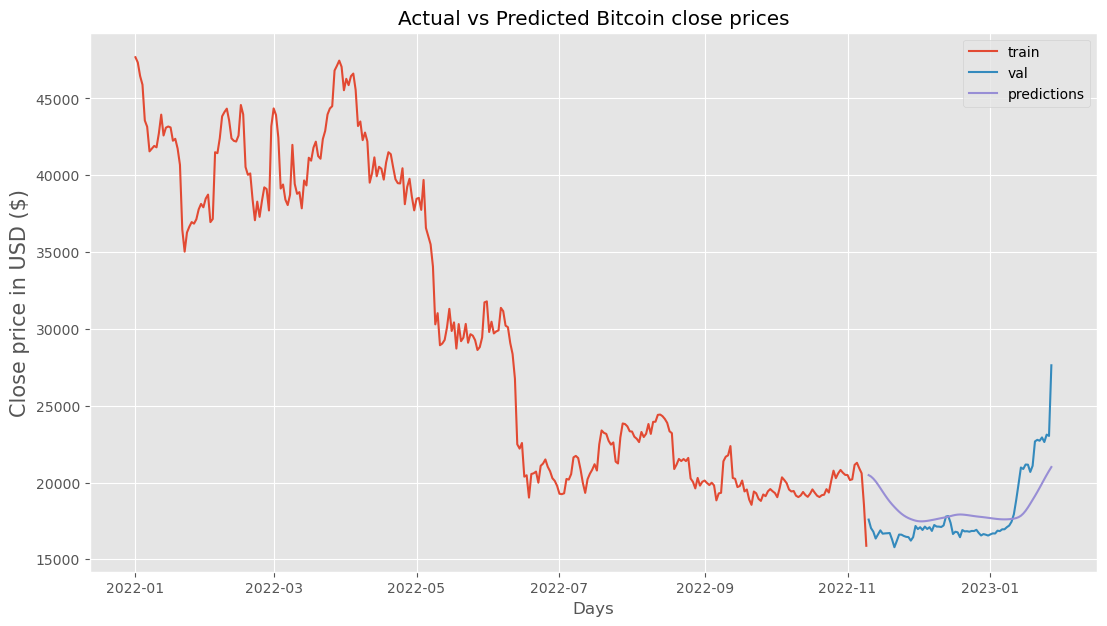

In [36]:
#We next visualize what we have done. 

train = data_new[:len_training_data]
valid = data_new[len_training_data:]
valid['predictions'] = predictions
plt.figure(figsize=(13, 7))
plt.plot(train['Close'])
plt.plot(valid[['Close', 'predictions']])
plt.title('Actual vs Predicted Bitcoin close prices')
plt.xlabel('Days')
plt.ylabel('Close price in USD ($)', fontsize=15)
plt.legend(['train', 'val', 'predictions'], loc='upper right')
plt.grid(True)
plt.show()

In [37]:
predictions[-future_days:]

array([[17741.94 ],
       [17723.031],
       [17702.807],
       [17681.643],
       [17660.512],
       [17641.045],
       [17623.701],
       [17610.855],
       [17602.695],
       [17600.238],
       [17602.889],
       [17611.494],
       [17626.463],
       [17649.62 ],
       [17685.543],
       [17743.996],
       [17837.342],
       [17977.104],
       [18159.693],
       [18378.012],
       [18621.312],
       [18872.83 ],
       [19124.186],
       [19386.094],
       [19659.518],
       [19939.176],
       [20220.387],
       [20493.666],
       [20757.37 ],
       [21007.564]], dtype=float32)

In [38]:
valid[-future_days:]

,Close,predictions
Date,,
2022-12-29,16642.341797,17741.939453
2022-12-30,16602.585938,17723.031250
2022-12-31,16547.496094,17702.806641
2023-01-01,16625.080078,17681.642578
2023-01-02,16688.470703,17660.511719
2023-01-03,16679.857422,17641.044922
2023-01-04,16863.238281,17623.701172
2023-01-05,16836.736328,17610.855469
2023-01-06,16951.968750,17602.695312


### 10. Conclusion.

- As we have seen, the LSTM model was not very perfect in predicting the actual close prices. This could be due to the depth 
<br>or the amount of data we have used in our analysis


- Bitcoin price movement has been highly volatile over the last couple of years which explains some disparities in the predictions 


- Usually, The LSTM does well with long-termed trend in our data but in this project we have only used data from a year ago.


- As seen from the actual and predicted bitcoin close price, the model was able predict the pattern of the the price movement.


- The prediction graph was able to show the decline in bticoin price movement in the month of November 2022 through<br> to mid-Jan 2023 there the price began to rise. Although, it did not show every detail of this<br> movement as compared to the actual price movement. A reason for this could be the high volatility of the price <br>
movement 
or due to the amount of data we have used for our prediction.


- In conclusion we can improve on the prediction by feeding the model with more data.